# Entrainement — CVAE Conditionnel SWI

Charge les donnees preprocessees depuis `data/maps/` et entraine le CVAE.
Sauvegarde le modele dans `models/cvae_swi.pth`.

> **Pre-requis** : avoir execute `preprocessing.ipynb` au prealable.

## 1. Imports et chargement des donnees preprocessees

In [1]:
import sys, torch, torch.nn as nn, numpy as np, json, gc
import pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

# Détection automatique de la racine du projet
ROOT_DIR   = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
MAPS_DIR   = ROOT_DIR / 'data' / 'maps'
MODELS_DIR = ROOT_DIR /'training_notebook' /'models'
MODELS_DIR.mkdir(exist_ok=True, parents=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Import des architectures (models_archi.py est dans le dossier parent)
sys.path.insert(0, str(ROOT_DIR))
from models_archi import COND_DIM, SWIMapDataset, Encoder, Decoder, CVAE

print(f'Device : {device}')

Device : cpu


## 1b. Configuration — dimension latente

> Ajustez  selon les resultats de l'ACP dans 
> (valeur N telle que ~90% de la variance est expliquee).

In [2]:
# ============================================================
# CHOIX DE LA DIMENSION LATENTE
# Lisez le résultat de l'ACP (preprocessing_cartes.ipynb) :
#   80% variance -> N composantes
#   90% variance -> N composantes  <-- recommande
#   95% variance -> N composantes
# Mettez la valeur correspondant au seuil 90% ci-dessous.
# ============================================================
LATENT_DIM = 10  # <- modifier ici

print(f"LATENT_DIM = {LATENT_DIM}")

LATENT_DIM = 10


In [3]:
with open(MAPS_DIR / 'metadata.json') as f:
    meta = json.load(f)

H, W         = meta['H'], meta['W']
H_pad, W_pad = meta['H_pad'], meta['W_pad']
STEP         = meta['STEP']
months_arr   = np.array(meta['months'], dtype=np.int32)
years_arr    = np.array(meta['years'],  dtype=np.int32)
monthly_stats = {int(k): tuple(v) for k, v in meta['monthly_stats'].items()}

swi_padded  = np.load(MAPS_DIR / 'swi_padded.npy')
swi_maps    = np.load(MAPS_DIR / 'swi_maps.npy')
land_mask   = np.load(MAPS_DIR / 'land_mask.npy')
mask_padded = np.load(MAPS_DIR / 'mask_padded.npy')
mask_tensor = torch.from_numpy(mask_padded)

T = len(months_arr)
print(f'Donnees chargees : swi_padded {swi_padded.shape}  |  T={T}')
print(f'Grille : {H}x{W} crop  ->  {H_pad}x{W_pad} padde')

Donnees chargees : swi_padded (780, 136, 136)  |  T=780
Grille : 133x131 crop  ->  136x136 padde


## 2. Dataset + DataLoader

In [4]:
BATCH_SIZE = 16
mask_train = years_arr < 2018
mask_test  = years_arr >= 2018

train_loader = DataLoader(
    SWIMapDataset(swi_padded[mask_train], months_arr[mask_train]),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader = DataLoader(
    SWIMapDataset(swi_padded[mask_test],  months_arr[mask_test]),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train {sum(mask_train)} | Test {sum(mask_test)}')

Train 696 | Test 84


## 3. Architecture CVAE

In [5]:
model = CVAE(H_pad, W_pad, latent_dim=LATENT_DIM).to(device)
print(f'CVAE : {sum(p.numel() for p in model.parameters() if p.requires_grad):,} params | LATENT_DIM={LATENT_DIM}')

CVAE : 38,193,013 params | LATENT_DIM=10


## 4. Entrainement

In [6]:
FREE_BITS = 0.5  # nats minimum par dimension latente

def elbo_loss(x, x_hat, mu, lv, mask, beta=1.0):
    m = mask[None, None]
    recon = ((x - x_hat)**2 * m).sum() / (x.size(0) * mask.sum())
    # Free bits : clamp par dimension pour eviter le KL collapse
    kl_per_dim = -0.5 * (1 + lv - mu.pow(2) - lv.exp())   # (B, latent_dim)
    kl = kl_per_dim.clamp(min=FREE_BITS).sum(1).mean()
    return recon + beta * kl, recon.item(), kl_per_dim.mean().item()

def run_epoch(model, loader, mask, beta, opt=None):
    model.train(opt is not None)
    tot = rec = kld = 0.0
    ctx = torch.enable_grad() if opt else torch.no_grad()
    with ctx:
        for x, c, _ in loader:
            x, c = x.to(device), c.to(device)
            xh, mu, lv = model(x, c)
            loss, r, kl = elbo_loss(x, xh, mu, lv, mask, beta)
            if opt:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0); opt.step()
            tot += loss.item(); rec += r; kld += kl
    n = len(loader)
    return tot/n, rec/n, kld/n

In [7]:
N_EPOCHS, LR, WARMUP, PATIENCE = 150, 3e-4, 20, 15

opt      = torch.optim.Adam(model.parameters(), lr=LR)
sch      = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS, eta_min=1e-5)
mask_dev = mask_tensor.to(device)
history  = {'tr':[], 'va':[], 'rec':[], 'kl':[]}

best_val, no_improve, best_state = float('inf'), 0, None

header = f"{'Ep':>4}  {'b':>4}  {'Train':>8}  {'Val':>8}  {'Rec':>8}  {'KL':>7}"
print(header)
print('-'*48)
for ep in range(1, N_EPOCHS+1):
    beta = min(1.0, ep/WARMUP)
    tr, r, kl = run_epoch(model, train_loader, mask_dev, beta, opt)
    va, _,  _ = run_epoch(model, test_loader,  mask_dev, beta)
    sch.step()
    for k,v in zip(['tr','va','rec','kl'],[tr,va,r,kl]): history[k].append(v)
    if ep % 10 == 0 or ep == 1:
        print(f'{ep:4d}  {beta:4.2f}  {tr:8.4f}  {va:8.4f}  {r:8.4f}  {kl:7.4f}')

    # Early stopping (uniquement apres le warmup)
    if ep > WARMUP:
        if va < best_val - 1e-4:
            best_val, no_improve = va, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'Early stop epoch {ep} — meilleure val : {best_val:.4f}')
                break

if best_state:
    model.load_state_dict(best_state)
print('Termine.')

  Ep     b     Train       Val       Rec       KL
------------------------------------------------
   1  0.05    2.6600    0.7064    0.8607   3.4068
  10  0.50    2.9668    2.9478    0.4161   0.2249
  20  1.00    5.4016    5.4019    0.3808   0.2422
  30  1.00    5.3356    5.3117    0.3266   0.2921
  40  1.00    5.3309    5.3057    0.3187   0.3295
  50  1.00    5.3136    5.3002    0.3047   0.3524
  60  1.00    5.2890    5.2790    0.2827   0.3575
  70  1.00    5.2906    5.2879    0.2838   0.3685
  80  1.00    5.2802    5.2740    0.2752   0.3884
  90  1.00    5.2666    5.2719    0.2625   0.4092
Early stop epoch 99 — meilleure val : 5.2643
Termine.


## 5. Sauvegarde du modele

In [8]:
torch.save(model.state_dict(), MODELS_DIR / 'cvae_swilat10.pth')
torch.save(history,            MODELS_DIR / 'cvae_historylat10.pt')

# Sauvegarde de la config pour que results.ipynb utilise le bon LATENT_DIM
import json as _json
with open(MODELS_DIR / 'cvae_config.json', 'w') as _f:
    _json.dump({'LATENT_DIM': LATENT_DIM}, _f)

print(f'Modele sauvegarde : models/cvae_swilat10.pth  (LATENT_DIM={LATENT_DIM})')

Modele sauvegarde : models/cvae_swilat10.pth  (LATENT_DIM=10)


## 6. Courbes d'entrainement

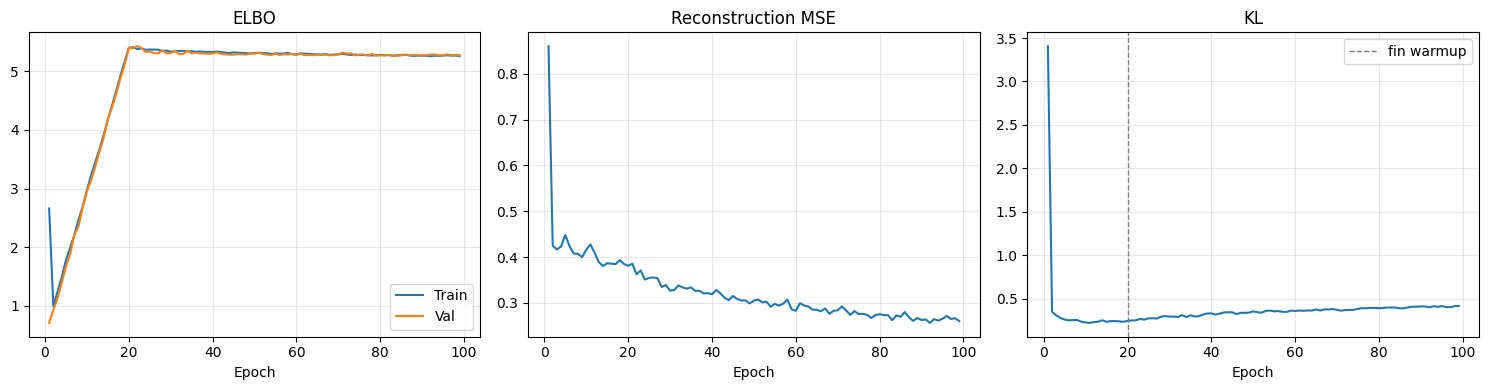

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
eps = range(1, len(history['tr'])+1)
axes[0].plot(eps, history['tr'], label='Train'); axes[0].plot(eps, history['va'], label='Val')
axes[0].set_title('ELBO'); axes[0].legend()
axes[1].plot(eps, history['rec']); axes[1].set_title('Reconstruction MSE')
axes[2].plot(eps, history['kl'])
axes[2].axvline(WARMUP, ls='--', c='gray', lw=1, label='fin warmup')
axes[2].set_title('KL'); axes[2].legend()
for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()